np.linalg.eig time: 2.386324405670166
1.0
norm_Av: 3.464823e+01
norm_lambda_v: 3.464823e+01
Error: 2.012751e-15
loop cost: 1061
1.0
norm_Av: 3.464823e+01
norm_lambda_v: 3.464823e+01
Error: 3.742074e-12
arnoldi + qr time: 5.387338638305664
1.0000000000000002
norm_Av: 3.171149e+00
norm_lambda_v: 3.464823e+01
Error: 1.073674e+01
loop cost: 1056
1.0
norm_Av: 3.464823e+01
norm_lambda_v: 3.464823e+01
Error: 3.742074e-12
chebyshev + arnoldi + qr time: 5.135394334793091
1.0
norm_Av: 3.000443e+01
norm_lambda_v: 3.464823e+01
Error: 1.822695e-01


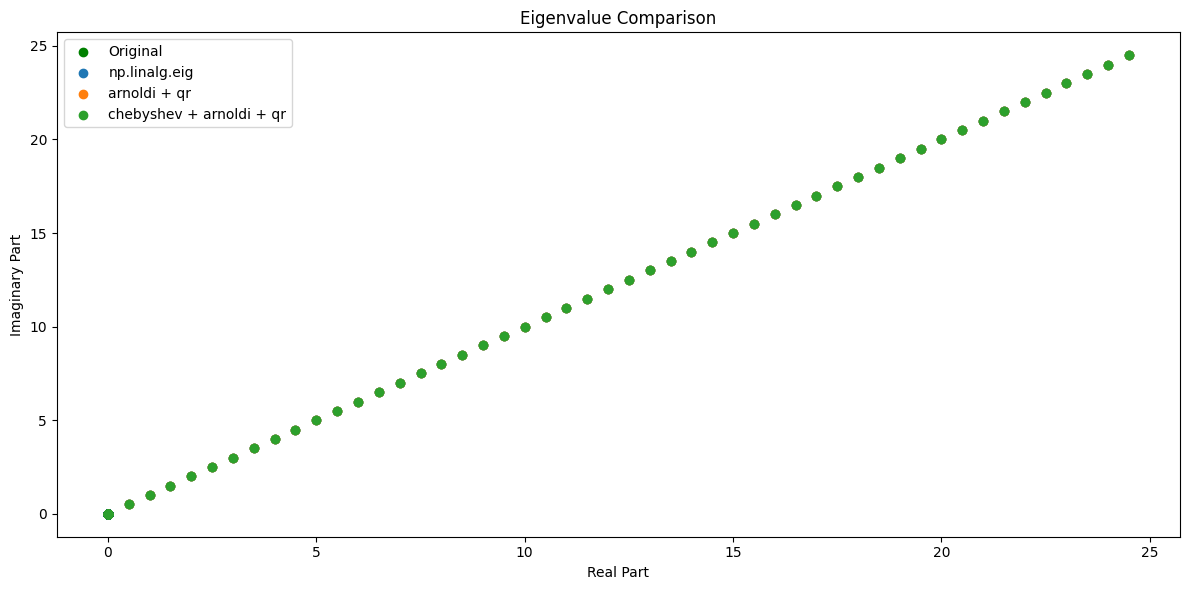

In [7]:
import time
# import cupy as np
import numpy as np
import matplotlib.pyplot as plt


def np_diag(input):
    if input.ndim == 1:
        n = len(input)
        diag_matrix = np.zeros((n, n), dtype=input.dtype)
        for i in range(n):
            diag_matrix[i, i] = input[i]
        return diag_matrix
    elif input.ndim == 2:
        return np.array([input[i, i] for i in range(min(input.shape))], dtype=input.dtype)
    else:
        raise ValueError(
            "Input must be a one-dimensional or two-dimensional array.")


def np_qr(A, tol=1e-9):
    m, n = A.shape
    Q = np.zeros((m, n), dtype=np.complex128)
    R = np.zeros((n, n), dtype=np.complex128)

    for j in range(n):
        v = A[:, j]
        for i in range(j):
            R[i, j] = np.dot(Q[:, i].conj(), v)
            v -= R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        if R[j, j] > tol:
            Q[:, j] = v / R[j, j]

    return Q, R


def np_orth(A, tol=1e-9):
    Q, R = np_qr(A)
    rank = np.sum(np.abs(np_diag(R)) > tol)
    return Q[:, :rank]


def generate_sparse_matrix_complex(eigenvalues, eigenvectors):
    n = len(eigenvalues)
    D = np.zeros((n, n), dtype=np.complex128)
    for i in range(n):
        D[i, i] = eigenvalues[i]

    A = eigenvectors @ D @ eigenvectors.conj().T
    return A


def apply_chebyshev_polynomial(A, v, degree):
    T = np.zeros((A.shape[0], degree+1), dtype=np.complex128)
    T[:, 0] = v
    T[:, 1] = A @ v

    for k in range(2, degree+1):
        T[:, k] = 2 * A @ T[:, k-1] - T[:, k-2]
    return T[:, -1]


def arnoldi_iteration_complex(A, k, v):
    n = A.shape[0]
    Q = np.zeros((n, k+1), dtype=np.complex128)
    H = np.zeros((k+1, k), dtype=np.complex128)
    q = v / np.linalg.norm(v)
    Q[:, 0] = q

    for j in range(k):
        v = A @ Q[:, j]
        for i in range(j+1):
            H[i, j] = np.dot(Q[:, i].conj(), v)
            v -= H[i, j] * Q[:, i]
        H[j+1, j] = np.linalg.norm(v)
        if H[j+1, j] != 0 and j+1 < n:
            Q[:, j+1] = v / H[j+1, j]
    return Q[:, :-1], H


def validate_eigenvector_complex(A, eigenvalues, eigenvectors):
    eigenvalue, eigenvector = eigenvalues[0], eigenvectors[:, 0]
    print(np.linalg.norm(eigenvector))
    Av = A @ eigenvector
    lambda_v = eigenvalue * eigenvector
    norm_Av = np.linalg.norm(Av)
    print(f"norm_Av: {norm_Av:.6e}")
    norm_lambda_v = np.linalg.norm(lambda_v)
    print(f"norm_lambda_v: {norm_lambda_v:.6e}")
    error = np.linalg.norm(Av - lambda_v) / norm_Av
    print(f"Error: {error:.6e}")


def qr_algorithm_complex(H, max_iter=5000, tol=1e-9):
    n = H.shape[0]
    for _ in range(max_iter):
        Q, R = np_qr(H)
        H = R @ Q[:H.shape[1], :]
        if np.all(np.abs(H - np_diag(np_diag(H))) < tol):
            print(f"loop cost: {_}")
            break
        if _==max_iter-1:
            print(f"loop cost: {_}")
    eigenvalues = np_diag(H)
    validate_eigenvector_complex(H, eigenvalues, Q)
    return eigenvalues, Q


def main():
    N = 1000
    n = 50
    degree = 5
    k = 60  # Increase Krylov subspace dimension
    max_iter = 10000  # Increase QR algorithm iterations
    plt.figure(figsize=(12, 6))

    eigenvalues = np.array([i * 0.5 + 1j * (i * 0.5)
                           for i in range(n)] + [0] * (N-n))
    eigenvectors = np_orth(np.random.rand(N, N) + 1j * np.random.rand(N, N))
    A = generate_sparse_matrix_complex(eigenvalues, eigenvectors)
    v = np.random.rand(N) + 1j * np.random.rand(N)
    plt.scatter(np.real(eigenvalues), np.imag(
        eigenvalues), color='g', label='Original')

    # Method 1: Directly using np.linalg.eig
    start_time = time.time()
    _eigenvalues, _eigenvectors = np.linalg.eig(A)
    end_time = time.time()
    _time = end_time - start_time
    plt.scatter(np.real(_eigenvalues), np.imag(
        _eigenvalues), label='np.linalg.eig')
    print("np.linalg.eig time:", _time)
    validate_eigenvector_complex(A, _eigenvalues, _eigenvectors)

    # Method 2: QR # cost too much time......
    # start_time = time.time()
    # H = A
    # _eigenvalues, _eigenvectors = qr_algorithm_complex(H, max_iter=max_iter)
    # end_time = time.time()
    # _time = end_time - start_time
    # plt.scatter(np.real(_eigenvalues), np.imag(
    #     _eigenvalues), label='qr')
    # print("qr time:", _time)
    # validate_eigenvector_complex(A, _eigenvalues, _eigenvectors)

    # Method 3: Arnoldi + QR
    start_time = time.time()
    Q, H = arnoldi_iteration_complex(A, k, v)
    _eigenvalues, _eigenvectors = qr_algorithm_complex(H, max_iter=max_iter)
    _eigenvectors = Q @ _eigenvectors
    end_time = time.time()
    _time = end_time - start_time
    plt.scatter(np.real(_eigenvalues), np.imag(
        _eigenvalues), label='arnoldi + qr')
    print("arnoldi + qr time:", _time)
    validate_eigenvector_complex(A, _eigenvalues, _eigenvectors)

    # Method 4: Chebyshev + Arnoldi + QR
    start_time = time.time()
    v_chebyshev = apply_chebyshev_polynomial(A, v, degree)
    Q, H = arnoldi_iteration_complex(A, k, v_chebyshev)
    _eigenvalues, _eigenvectors = qr_algorithm_complex(H, max_iter=max_iter)
    _eigenvectors = Q @ _eigenvectors
    end_time = time.time()
    _time = end_time - start_time
    plt.scatter(np.real(_eigenvalues), np.imag(
        _eigenvalues), label='chebyshev + arnoldi + qr')
    print("chebyshev + arnoldi + qr time:", _time)
    validate_eigenvector_complex(A, _eigenvalues, _eigenvectors)

    # Plot eigenvalue comparison
    plt.xlabel('Real Part')
    plt.ylabel('Imaginary Part')
    plt.title('Eigenvalue Comparison')
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
import numpy as np

# Arnoldi 迭代
def arnoldi_iteration(A, k):
    n = A.shape[0]
    Q = np.zeros((n, k), dtype=np.complex128)  # 用于存储基向量的矩阵
    H = np.zeros((k, k), dtype=np.complex128)  # 用于存储 Hessenberg 矩阵 H
    q = np.random.rand(n) + 1j * np.random.rand(n)  # 随机生成复数初始向量
    q = q / np.linalg.norm(q)  # 将向量 q 归一化
    Q[:, 0] = q  # 将归一化后的 q 作为第一个基向量

    for j in range(k - 1):
        v = A @ Q[:, j]  # v = A * qj
        for i in range(j + 1):
            H[i, j] = np.dot(Q[:, i].conj(), v)  # 计算 H[i, j]
            v -= H[i, j] * Q[:, i]  # Gram-Schmidt 正交化过程
        H[j + 1, j] = np.linalg.norm(v)  # 计算 H[j+1, j] 的值
        if H[j + 1, j] != 0:
            Q[:, j + 1] = v / H[j + 1, j]  # 归一化 v
    return Q, H  # 返回正交基矩阵 Q 和上 Hessenberg 矩阵 H

# 使用 Arnoldi 迭代生成 Krylov 子空间
n = 100  # 矩阵维度
k = 10   # 子空间维度
A = np.random.rand(n, n) + 1j * np.random.rand(n, n)  # 随机生成复矩阵 A

Q, H = arnoldi_iteration(A, k)

# 计算 H 的特征值和特征向量
eigenvalues_H, eigenvectors_H = np.linalg.eig(H)

# 排序特征值和特征向量
idx = np.argsort(np.abs(eigenvalues_H))[::-1]  # 按特征值的绝对值从大到小排序
eigenvalues_H_sorted = eigenvalues_H[idx]
eigenvectors_H_sorted = eigenvectors_H[:, idx]
# eigenvalues_H_sorted = eigenvalues_H
# eigenvectors_H_sorted = eigenvectors_H

# eigenvalues_H_sorted = eigenvalues_H
# eigenvectors_H_sorted = eigenvectors_H

# 通过 Q 将 H 的特征向量映射到原始矩阵 A 的特征向量空间
eigenvectors_A = Q @ eigenvectors_H_sorted

# 输出计算的特征值和特征向量
print("H 的特征值：", eigenvalues_H_sorted)
print("映射回 A 的特征向量：", eigenvectors_A)

# 验证特征向量和特征值的关系
def validate_eigenvector_complex(A, eigenvalue, eigenvector, tol=1e-6):
    Av = A @ eigenvector
    lambda_v = eigenvalue * eigenvector
    error = np.linalg.norm(Av - lambda_v)/np.linalg.norm(Av)
    print("误差：", error)
    return error < tol  # 如果误差小于容忍度，认为验证成功

# 验证特征向量的准确性
eigenvector_error = validate_eigenvector_complex(
    A, eigenvalues_H_sorted[0], eigenvectors_A[:, 0])
print(f"特征向量的验证结果：{'通过' if eigenvector_error else '未通过'}")


H 的特征值： [49.58908467+50.42736274j  3.80105795 +0.16100251j
  0.10602184 +3.58307408j -3.4793582  +0.77083854j
  2.16153565 -2.78483131j  2.59957345 +1.85232648j
 -0.49902969 -3.09611614j -1.98291442 -2.2253784j
 -1.29549585 +2.28802608j  0.         +0.j        ]
映射回 A 的特征向量： [[ 6.95486953e-02+7.19510689e-02j -3.98266974e-02-1.12445909e-01j
   1.72661879e-01-1.05475865e-02j  4.04252704e-02-6.51256429e-02j
  -9.95640195e-02-8.20946421e-02j  6.14963315e-02-2.26784416e-01j
  -3.21020559e-02+6.79344853e-02j  6.01142737e-02-2.20250108e-02j
   2.60332959e-02-1.54236851e-02j  2.29402396e-02-1.01022829e-01j]
 [ 6.75355135e-02+7.38686787e-02j  4.20523898e-02+1.08291545e-01j
   1.26026619e-01+7.01011052e-02j  2.13245372e-02+1.35111561e-01j
  -1.83304835e-02+8.69461304e-02j -1.07461666e-02+1.23787216e-01j
   4.43878444e-02-3.23337097e-02j -9.68941958e-02+2.53020862e-02j
   3.93143800e-02+1.77891703e-01j  2.00655707e-02+1.50551658e-01j]
 [ 6.82081030e-02+6.52294572e-02j -6.54298340e-02-4.81263953e-